# Notebook for Displaying Results

## Imports / Constants / Shared Helpers

In [1]:
from __future__ import annotations

import importlib
import json
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS_DIR = Path('results')
FIGURES_DIR = Path('figures')
SUMMARY_FILE = 'all_results_summary.csv'
ESTIMATOR_FILE = 'estimators.csv'
SETTINGS_PACKAGE = 'configs.experiment_settings'
SETTINGS_DIR = Path('configs/experiment_settings')
RANDOM_PARA_SWEEP_COL = '__random_para_sweep_value'

LONG_DF_COLUMNS = [
    'setting',
    'folder',
    'x_raw',
    'x_label',
    'method',
    'estimate',
    'truth',
    'error',
    'squared_error',
]

CANDIDATE_SWEEP_KEYS = [
    'phi_varphi_theta_shift',
    'graph',
    'pi',
    'm',
    'n',
    'random_para_dist_name',
    'random_para_c_by_param',
]


def list_setting_names(settings_dir: Path = SETTINGS_DIR) -> list[str]:
    return sorted(
        p.stem
        for p in settings_dir.glob('*.py')
        if p.stem not in {'__init__', 'current_setting'}
    )


def load_experiment_setting(setting_name: str) -> dict[str, Any]:
    module = importlib.import_module(f'{SETTINGS_PACKAGE}.{setting_name}')
    setting = getattr(module, 'EXPERIMENT_SETTING', None)
    if not isinstance(setting, dict):
        raise TypeError(f'EXPERIMENT_SETTING missing or invalid in {setting_name}')
    return dict(setting)


def format_scalar(value: Any) -> str:
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    if isinstance(value, (float, np.floating)):
        x = float(value)
        if np.isnan(x):
            return 'nan'
        if abs(x - round(x)) < 1e-10:
            return str(int(round(x)))
        return f'{x:.3g}'
    return str(value)


def format_metric_label(metric_name: str, metric_label: str | None = None) -> str:
    if metric_label is not None:
        return metric_label
    if metric_name == 'GTE_ra':
        return r'$\mathrm{GTE}^{\mathrm{ra}}$'
    if metric_name == 'GT_ra':
        return r'$\mathrm{GT}^{\mathrm{ra}}$'
    if metric_name == 'GC_ra':
        return r'$\mathrm{GC}^{\mathrm{ra}}$'
    return metric_name


def method_style_maps(
    methods: list[str],
    method_label_map: dict[str, str] | None = None,
    method_colors: list[str] | None = None,
) -> tuple[dict[str, str], dict[str, Any]]:
    labels = {method: method_label_map.get(method, method) if method_label_map else method for method in methods}
    if method_colors:
        colors = {method: method_colors[i % len(method_colors)] for i, method in enumerate(methods)}
    else:
        cmap = plt.get_cmap('tab10')
        colors = {method: cmap(i % 10) for i, method in enumerate(methods)}
    return labels, colors


def _parse_json_dict(value: Any) -> dict[str, Any] | None:
    if isinstance(value, dict):
        return value
    if not isinstance(value, str):
        return None
    text = value.strip()
    if not (text.startswith('{') and text.endswith('}')):
        return None
    try:
        parsed = json.loads(text)
    except json.JSONDecodeError:
        return None
    return parsed if isinstance(parsed, dict) else None


def _resolve_random_para_c_sweep(summary_df: pd.DataFrame, setting: dict[str, Any]) -> str | None:
    if 'random_para_c_by_param' not in summary_df.columns:
        return None
    parsed_rows = [_parse_json_dict(value) for value in summary_df['random_para_c_by_param']]
    if any(row is None for row in parsed_rows):
        return None
    keys = sorted({key for row in parsed_rows for key in row})
    varying = [
        key
        for key in keys
        if pd.Series([row.get(key) for row in parsed_rows]).nunique(dropna=True) > 1
    ]
    if not varying:
        return None
    chosen_key = varying[0]
    summary_df[RANDOM_PARA_SWEEP_COL] = [row.get(chosen_key) for row in parsed_rows]
    setting.setdefault('x_axis_label', chosen_key)
    return RANDOM_PARA_SWEEP_COL


def _lookup_label(label_map: dict[Any, Any], value: Any) -> str | None:
    for key in (value, str(value), format_scalar(value)):
        try:
            if key in label_map:
                return str(label_map[key])
        except TypeError:
            continue
    return None


ZERO_DISTURBANCE_LABELS = {'0', '0.0', '0.00'}
ZERO_DISTURBANCE_RAW_VALUES = {'phi_0_0_var_0_0_t_0_0'}


def is_disturbance_axis(axis_meta: dict[str, Any]) -> bool:
    sweep_key = str(axis_meta.get('sweep_key', '')).lower()
    axis_label = str(axis_meta.get('axis_label', '')).lower()
    return sweep_key in {'phi_varphi_theta_shift', 'phi'} or 'disturbance' in axis_label


def display_axis_label(axis_meta: dict[str, Any]) -> str:
    if is_disturbance_axis(axis_meta):
        return r'Disturbance level $\Delta$'
    return str(axis_meta.get('axis_label', ''))


def is_zero_disturbance_case(raw_value: Any, x_label: Any | None = None) -> bool:
    raw_text = str(raw_value).strip()
    label_text = str(x_label).strip() if x_label is not None else ''
    if raw_text in ZERO_DISTURBANCE_RAW_VALUES or label_text in ZERO_DISTURBANCE_LABELS:
        return True
    try:
        return abs(float(raw_value)) < 1e-12
    except (TypeError, ValueError):
        return False


def resolve_sweep_key(
    summary_df: pd.DataFrame,
    setting_name: str,
    setting: dict[str, Any] | None = None,
    sweep_key_override: str | None = None,
) -> str:
    setting = setting or {}
    if sweep_key_override:
        if sweep_key_override not in summary_df.columns:
            raise ValueError(f'sweep_key_override={sweep_key_override} not found for {setting_name}')
        return sweep_key_override

    configured = setting.get('x_sweep_key')
    if configured:
        if configured == 'random_para_c_by_param':
            derived = _resolve_random_para_c_sweep(summary_df, setting)
            if derived is not None:
                return derived
        if configured not in summary_df.columns:
            raise ValueError(f'x_sweep_key={configured} not found for {setting_name}')
        return str(configured)

    derived = _resolve_random_para_c_sweep(summary_df, setting)
    if derived is not None:
        return derived

    varying = [
        key
        for key in CANDIDATE_SWEEP_KEYS
        if key in summary_df.columns and summary_df[key].nunique(dropna=True) > 1
    ]
    if not varying:
        raise ValueError(f'No varying sweep key found for {setting_name}')
    return 'graph' if 'graph' in varying else varying[0]


def infer_axis_meta(setting: dict[str, Any], sweep_key: str, observed_values: list[Any]) -> dict[str, Any]:
    axis_label = str(setting.get('x_axis_label', sweep_key))
    configured_order = list(setting.get('x_value_order', []))
    configured_labels = setting.get('x_value_labels', {})
    if not isinstance(configured_labels, dict):
        configured_labels = {}

    order = [value for value in configured_order if value in observed_values]
    for value in observed_values:
        if value not in order:
            order.append(value)

    labels = {}
    for value in order:
        labels[value] = _lookup_label(configured_labels, value) or format_scalar(value)

    axis_meta = {
        'axis_label': axis_label,
        'order_raw': order,
        'label_map': labels,
        'sweep_key': sweep_key,
    }
    axis_meta['axis_label'] = display_axis_label(axis_meta)
    return axis_meta


def _append_estimator_rows(
    rows: list[pd.DataFrame],
    est_df: pd.DataFrame,
    methods: list[str],
    truth_col: str,
    setting: str,
    folder: str,
    x_raw: Any,
    x_label: str,
) -> None:
    has_truth = truth_col in est_df.columns
    for method in methods:
        if method not in est_df.columns:
            print(f'[warn] missing method={method} in {folder}')
            continue
        frame = pd.DataFrame({'estimate': pd.to_numeric(est_df[method], errors='coerce')})
        if has_truth:
            frame['truth'] = pd.to_numeric(est_df[truth_col], errors='coerce')
        else:
            frame['truth'] = np.nan
        frame['setting'] = setting
        frame['folder'] = folder
        frame['x_raw'] = x_raw
        frame['x_label'] = str(x_label)
        frame['method'] = method
        frame['error'] = frame['estimate'] - frame['truth']
        frame['squared_error'] = frame['error'] ** 2
        rows.append(frame[LONG_DF_COLUMNS])


def remove_zero_disturbance_cases(
    long_df: pd.DataFrame,
    meta: dict[str, Any],
) -> tuple[pd.DataFrame, dict[str, Any]]:
    settings = meta.get('settings', {})
    if long_df.empty or not settings:
        return long_df, meta

    filtered_df = long_df
    for setting, setting_meta in settings.items():
        setting_meta['axis_label'] = display_axis_label(setting_meta)
        if not is_disturbance_axis(setting_meta):
            continue

        order = list(setting_meta.get('order_raw', []))
        label_map = dict(setting_meta.get('label_map', {}))
        drop_values = [
            value
            for value in order
            if is_zero_disturbance_case(value, label_map.get(value))
        ]
        if not drop_values:
            continue

        drop_set = set(drop_values)
        setting_mask = filtered_df['setting'].eq(setting)
        filtered_df = filtered_df.loc[
            ~(setting_mask & filtered_df['x_raw'].isin(drop_set))
        ].copy()
        setting_meta['order_raw'] = [value for value in order if value not in drop_set]
        setting_meta['label_map'] = {
            value: label for value, label in label_map.items() if value not in drop_set
        }

    return filtered_df.reset_index(drop=True), meta


## Standard Sweep Loader

In [2]:
from __future__ import annotations


def _standard_summary_path(results_root: Path, setting_name: str) -> tuple[Path, Path]:
    nested = results_root / setting_name / SUMMARY_FILE
    if nested.exists():
        return nested, results_root / setting_name
    direct = results_root / SUMMARY_FILE
    if direct.exists():
        return direct, results_root
    raise FileNotFoundError(f'Missing {SUMMARY_FILE} for {setting_name} under {results_root}')


def load_standard_sweep(
    results_root: Path,
    selected_settings: list[str],
    methods: list[str],
    truth_col: str,
    sweep_key_override: dict[str, str] | None = None,
) -> tuple[pd.DataFrame, dict[str, Any]]:
    all_rows: list[pd.DataFrame] = []
    meta_by_setting: dict[str, dict[str, Any]] = {}
    results_root = Path(results_root)
    sweep_key_override = sweep_key_override or {}

    for setting_name in selected_settings:
        setting = load_experiment_setting(setting_name)
        summary_path, setting_root = _standard_summary_path(results_root, setting_name)
        summary_df = pd.read_csv(summary_path)
        if 'folder' not in summary_df.columns:
            raise ValueError(f'folder column missing in {summary_path}')

        sweep_key = resolve_sweep_key(summary_df, setting_name, setting, sweep_key_override.get(setting_name))
        observed_values = list(pd.unique(summary_df[sweep_key]))
        axis_meta = infer_axis_meta(setting, sweep_key, observed_values)
        meta_by_setting[setting_name] = axis_meta

        for _, row in summary_df.iterrows():
            folder = row.get('folder')
            if not isinstance(folder, str) or not folder:
                continue
            est_path = setting_root / folder / ESTIMATOR_FILE
            if not est_path.exists():
                print(f'[warn] missing estimator file: {est_path}')
                continue
            x_raw = row[sweep_key]
            x_label = axis_meta['label_map'].get(x_raw, format_scalar(x_raw))
            _append_estimator_rows(
                all_rows,
                pd.read_csv(est_path),
                methods,
                truth_col,
                setting_name,
                folder,
                x_raw,
                x_label,
            )

    if not all_rows:
        raise ValueError('No standard sweep data loaded.')

    return pd.concat(all_rows, ignore_index=True), {
        'mode': 'standard',
        'results_root': results_root,
        'settings': meta_by_setting,
    }


## Manual Sweep Loader

In [3]:
from __future__ import annotations


def _resolve_experiment_root(exp_dir: str | Path, base_results_dir: Path = RESULTS_DIR) -> Path:
    exp_path = Path(exp_dir)
    return exp_path if exp_path.is_absolute() else Path(base_results_dir) / exp_path


def load_manual_folder_sweep(
    spec: dict[str, Any],
    methods: list[str],
    truth_col: str,
    base_results_dir: Path = RESULTS_DIR,
) -> tuple[pd.DataFrame, dict[str, Any]]:
    exp_root = _resolve_experiment_root(spec['exp_dir'], base_results_dir)
    setting_name = str(spec.get('name', Path(spec['exp_dir']).name))
    truth_col = str(spec.get('truth_col', truth_col))
    rows: list[pd.DataFrame] = []
    order: list[Any] = []
    labels: dict[Any, str] = {}

    for folder, x_raw, x_label in spec['folders']:
        order.append(x_raw)
        labels[x_raw] = str(x_label)
        est_path = exp_root / folder / ESTIMATOR_FILE
        if not est_path.exists():
            print(f'[warn] missing estimator file: {est_path}')
            continue
        _append_estimator_rows(
            rows,
            pd.read_csv(est_path),
            methods,
            truth_col,
            setting_name,
            folder,
            x_raw,
            str(x_label),
        )

    if not rows:
        raise ValueError('No manual sweep data loaded.')

    return pd.concat(rows, ignore_index=True), {
        'mode': 'manual',
        'results_root': exp_root,
        'settings': {
            setting_name: {
                'axis_label': display_axis_label({
                    'axis_label': str(spec.get('x_name', spec.get('x_key', 'manual'))),
                    'sweep_key': str(spec.get('x_key', 'manual')),
                }),
                'order_raw': order,
                'label_map': labels,
                'sweep_key': str(spec.get('x_key', 'manual')),
            }
        },
    }


## Metrics Helpers

In [4]:
from __future__ import annotations


def calc_metrics(long_df: pd.DataFrame) -> pd.DataFrame:
    missing = [column for column in LONG_DF_COLUMNS if column not in long_df.columns]
    if missing:
        raise ValueError(f'long_df missing required columns: {missing}')

    paired = long_df.dropna(subset=['estimate', 'truth']).copy()
    if paired.empty:
        return pd.DataFrame(
            columns=['setting', 'x_raw', 'x_label', 'method', 'n', 'bias', 'se', 'mse', 'estimate_mean', 'truth_mean']
        )

    return (
        paired.groupby(['setting', 'x_raw', 'x_label', 'method'], as_index=False, sort=False)
        .agg(
            n=('error', 'size'),
            bias=('error', 'mean'),
            se=('error', lambda s: float(np.std(s, ddof=1) / np.sqrt(len(s))) if len(s) > 1 else np.nan),
            mse=('squared_error', 'mean'),
            estimate_mean=('estimate', 'mean'),
            truth_mean=('truth', 'mean'),
        )
    )


def print_metrics_table(
    metrics_df: pd.DataFrame,
    methods: list[str],
    method_label_map: dict[str, str] | None = None,
) -> None:
    labels, _ = method_style_maps(methods, method_label_map)
    if metrics_df.empty:
        print('[warn] no paired estimator-truth data for metrics table')
        return

    for setting in metrics_df['setting'].drop_duplicates():
        print(f'\n=== {setting} ===')
        setting_df = metrics_df.loc[metrics_df['setting'] == setting]
        for x_label in setting_df['x_label'].drop_duplicates():
            one = setting_df.loc[setting_df['x_label'] == x_label]
            table = one.set_index('method').reindex(methods)[['bias', 'se', 'mse']]
            table.index = [labels.get(method, method) for method in table.index]
            print(f'[x={x_label}]')
            print(table.round(6).to_string())


## Plot Helpers

In [5]:
from __future__ import annotations


def _ordered_values(meta: dict[str, Any], setting: str, data_values: list[Any]) -> list[Any]:
    configured = meta['settings'][setting]['order_raw']
    ordered = [value for value in configured if value in data_values]
    for value in data_values:
        if value not in ordered:
            ordered.append(value)
    return ordered


def figure_size_for_order(order: list[Any]) -> tuple[float, float]:
    n_values = max(len(order), 1)
    width = 2.8 if n_values <= 3 else 0.65 * n_values + 0.85
    return width, 3.35


def plot_grouped_boxplot(
    long_df: pd.DataFrame,
    meta: dict[str, Any],
    methods: list[str],
    method_label_map: dict[str, str] | None = None,
    method_colors: list[str] | None = None,
    metric_name: str = 'GTE',
    metric_label: str | None = None,
    boxplot_mode: str = 'estimate',
    legend_pos: str = 'upper left',
    save_fig: bool = True,
) -> list[Path]:
    if boxplot_mode not in {'estimate', 'bias'}:
        raise ValueError("boxplot_mode must be 'estimate' or 'bias'")

    labels, colors = method_style_maps(methods, method_label_map, method_colors)
    saved_paths: list[Path] = []
    value_col = 'error' if boxplot_mode == 'bias' else 'estimate'
    metric_label_used = format_metric_label(metric_name, metric_label)
    ylabel = f'Bias ({metric_label_used})' if boxplot_mode == 'bias' else metric_label_used

    for setting, setting_df in long_df.groupby('setting', sort=False):
        setting_meta = meta['settings'][setting]
        order = _ordered_values(meta, setting, list(pd.unique(setting_df['x_raw'])))
        methods_in_data = [method for method in methods if method in set(setting_df['method'])]
        if not order or not methods_in_data:
            continue

        fig, ax = plt.subplots(figsize=figure_size_for_order(order))
        box_width = 0.6 / len(methods_in_data) * 0.85

        for j, method in enumerate(methods_in_data):
            data_to_plot = []
            for raw in order:
                values = setting_df.loc[
                    (setting_df['x_raw'] == raw) & (setting_df['method'] == method),
                    value_col,
                ].dropna().to_numpy()
                data_to_plot.append(values if values.size else np.array([np.nan]))
            offset = -0.3 + (j + 0.5) * (0.6 / len(methods_in_data))
            positions = [i + offset for i in range(len(order))]
            bp = ax.boxplot(
                data_to_plot,
                positions=positions,
                widths=box_width,
                patch_artist=True,
                showfliers=False,
                boxprops={'linewidth': 0.8},
                whiskerprops={'linewidth': 0.8},
                capprops={'linewidth': 0.8},
                medianprops={'linewidth': 0.8, 'color': 'black'},
                manage_ticks=False,
            )
            for patch in bp['boxes']:
                patch.set_facecolor(colors[method])
                patch.set_alpha(0.7)

        if boxplot_mode == 'bias':
            ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
        else:
            for i, raw in enumerate(order):
                truth = setting_df.loc[setting_df['x_raw'] == raw, 'truth'].dropna()
                if not truth.empty:
                    ax.hlines(float(truth.mean()), i - 0.5, i + 0.5, color='#07010f', linestyle='--', linewidth=0.8)

        for i in range(1, len(order)):
            ax.axvline(i - 0.5, color='gray', linestyle='--', linewidth=0.4, alpha=0.5)

        ax.set_xticks(range(len(order)))
        ax.set_xticklabels([setting_meta['label_map'].get(value, format_scalar(value)) for value in order])
        ax.set_xlim(-0.6, len(order) - 0.4)
        ax.set_xlabel(setting_meta['axis_label'], fontsize=8)
        ax.set_ylabel(ylabel, fontsize=8)
        ax.tick_params(axis='both', labelsize=7)

        handles = [plt.Rectangle((0, 0), 1, 1, facecolor=colors[method], alpha=0.7) for method in methods_in_data]
        ax.legend(
            handles,
            [labels[method] for method in methods_in_data],
            loc=legend_pos,
            fontsize=7,
            frameon=True,
            borderpad=0.2,
            labelspacing=0.2,
            handlelength=1.0,
            handletextpad=0.4,
        )
        plt.tight_layout()

        if save_fig:
            root_name = Path(meta['results_root']).name
            save_dir = FIGURES_DIR / root_name / setting
            save_dir.mkdir(parents=True, exist_ok=True)
            path = save_dir / f'{setting}_{setting_meta["sweep_key"]}_{metric_name}_{boxplot_mode}_boxplot.png'
            plt.savefig(path, dpi=600, bbox_inches='tight')
            saved_paths.append(path)
            print(f'Saved: {path}')
        plt.show()

    return saved_paths


def plot_mse_curve(
    metrics_df: pd.DataFrame,
    meta: dict[str, Any],
    methods: list[str],
    method_label_map: dict[str, str] | None = None,
    method_colors: list[str] | None = None,
    metric_name: str = 'GTE',
    legend_pos: str = 'upper left',
    legend_overrides_by_setting: dict[str, dict[str, Any]] | None = None,
    save_fig: bool = True,
) -> list[Path]:
    labels, colors = method_style_maps(methods, method_label_map, method_colors)
    saved_paths: list[Path] = []
    if metrics_df.empty:
        print('[warn] no MSE data to plot')
        return saved_paths

    for setting, setting_df in metrics_df.groupby('setting', sort=False):
        setting_meta = meta['settings'][setting]
        order = _ordered_values(meta, setting, list(pd.unique(setting_df['x_raw'])))
        methods_in_data = [method for method in methods if method in set(setting_df['method'])]
        if not order or not methods_in_data:
            continue

        fig, ax = plt.subplots(figsize=figure_size_for_order(order))
        x_pos = list(range(len(order)))
        for method in methods_in_data:
            y_values = []
            for raw in order:
                values = setting_df.loc[
                    (setting_df['x_raw'] == raw) & (setting_df['method'] == method),
                    'mse',
                ]
                y_values.append(float(values.iloc[0]) if not values.empty else np.nan)
            ax.plot(x_pos, y_values, marker='o', color=colors[method], label=labels[method], linewidth=0.7, markersize=5)

        ax.set_xticks(x_pos)
        ax.set_xticklabels([setting_meta['label_map'].get(value, format_scalar(value)) for value in order])
        ax.set_xlabel(setting_meta['axis_label'], fontsize=8)
        ax.set_ylabel('MSE', fontsize=8)
        ax.tick_params(axis='both', labelsize=7)
        ax.set_ylim(bottom=0)
        legend_kwargs = {
            'loc': legend_pos,
            'fontsize': 7,
            'frameon': True,
            'borderpad': 0.2,
            'labelspacing': 0.2,
            'handlelength': 1.5,
            'handletextpad': 0.4,
        }
        legend_kwargs.update((legend_overrides_by_setting or {}).get(setting, {}))
        ax.legend(**legend_kwargs)
        plt.tight_layout()

        if save_fig:
            root_name = Path(meta['results_root']).name
            save_dir = FIGURES_DIR / root_name / setting
            save_dir.mkdir(parents=True, exist_ok=True)
            path = save_dir / f'{setting}_{setting_meta["sweep_key"]}_{metric_name}_mse.png'
            plt.savefig(path, dpi=1000, bbox_inches='tight')
            saved_paths.append(path)
            print(f'Saved: {path}')
        plt.show()

    return saved_paths


## User Configuration

In [ ]:
# Choose which layout to load when Plot Results runs.
MODE = 'standard'  # 'standard' or 'manual'

# Common plotting config. These defaults apply to the main plot suite.
METHODS_TO_PLOT = [
    'naive_HT_share_GTE',
    'propagation_share_GTE',
    'cluster_mean_share_GTE',
    'proposed_share_GTE',
]
METHOD_LABELS = {
    'naive_HT_share_GTE': 'DM',
    'propagation_share_GTE': 'DM-FO',
    'cluster_mean_share_GTE': 'GCR',
    'bayesian_bgps_share_GTE': 'BGPS',
    'proposed_share_GTE': 'Ours',
    'split_credit2_react_GTE': 'EW',
    'split_credit_react_GTE': 'HEW',
    'proposed_react_GTE': 'Ours',
}
METHOD_COLORS = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c', '#9467bd']
GROUND_TRUTH_COL = 'truth_share_GTE'
METRIC_NAME = 'GTE'
METRIC_LABEL = None
BOXPLOT_MODE = 'estimate'  # 'estimate' or 'bias'
SAVE_FIG = True
LEGEND_POS = 'upper left'
MSE_LEGEND_OVERRIDES = {
    'barabasi_uniform_sweep_disturbance2': {
        'loc': 'center left',
        'bbox_to_anchor': (0.04, 0.55),
    },
}

# Standard layout: results/<experiment_root>/<setting_name>/all_results_summary.csv.
# main paper setting: barabasi_uniform_sweep_disturbance
STANDARD_RESULTS_ROOT = RESULTS_DIR / 'experiments_20260408_215638'
SELECTED_SETTINGS = [
    'barabasi_gamma_sweep_disturbance',
    'barabasi_lognormal_sweep_disturbance',
    'barabasi_uniform_more_shares',
    'barabasi_uniform_sweep_degree',
    'barabasi_uniform_sweep_disturbance',
    'barabasi_uniform_sweep_n',
    'watts_uniform_sweep_rewiring_p',
    'watts_uniform_sweep_degree',
    'sbm_uniform_sweep_block_num',
]
SWEEP_KEY_OVERRIDE: dict[str, str] = {}

# Extra standard plots run after the main standard suite. Set this to [] to skip them.
STANDARD_EXTRA_PLOTS = [
    {
        'name': 'barabasi_uniform_sweep_disturbance_GTE_ra',
        'selected_settings': ['barabasi_uniform_sweep_disturbance'],
        'methods': [
            'split_credit2_react_GTE',
            'split_credit_react_GTE',
            'proposed_react_GTE',
        ],
        'method_labels': {
            'split_credit2_react_GTE': 'EW',
            'split_credit_react_GTE': 'HEW',
            'proposed_react_GTE': 'Ours',
        },
        'method_colors': ['#d62728', '#9467bd', '#2ca02c'],
        'truth_col': 'truth_react_GTE',
        'metric_name': 'GTE_ra',
        'metric_label': None,
        'boxplot_mode': BOXPLOT_MODE,
        'legend_pos': 'upper left',
        'sweep_key_override': {},
    },
]

# Manual layout: curated folders under results/<exp_dir>/.
# A preset can override methods, truth_col, metric_name, metric_label, labels, and colors.
MANUAL_PRESET = 'rho0'  # 'rho0', 'W', or 'bayesian'
MANUAL_SPECS = {
    'rho0': {
        'name': 'manual_rho0',
        'exp_dir': 'experiments_20260410_195118',
        'x_key': 'rho0',
        'x_name': 'Actual rho0',
        'truth_col': 'truth_share_GTE',
        'folders': [
            ('rho0_target_0p05__actual_0p05__scale_0p3754', 0.05, '0.05'),
            ('rho0_target_0p2__actual_0p2__scale_1p5016', 0.2, '0.2'),
            ('rho0_target_0p5__actual_0p5__scale_3p7541', 0.5, '0.5'),
            ('rho0_target_0p8__actual_0p8__scale_6p0065', 0.8, '0.8'),
        ],
    },
    'W': {
        'name': 'manual_W',
        'exp_dir': 'experiments_20260410_195116',
        'x_key': 'W',
        'x_name': 'W',
        'truth_col': 'truth_share_GTE',
        'folders': [
            ('W_0', 0, '0'),
            ('W_5', 5, '5'),
            ('W_10', 10, '10'),
            ('W_24', 24, '24'),
            ('W_100', 100, '100'),
        ],
    },
    'bayesian': {
        'name': 'manual_bayesian',
        'exp_dir': 'experiments_20260410_195248',
        'x_key': 'phi',
        'x_name': r'Disturbance level $\Delta$',
        'truth_col': 'truth_share_GTE',
        'methods': [
            'naive_HT_share_GTE',
            'propagation_share_GTE',
            'cluster_mean_share_GTE',
            'bayesian_bgps_share_GTE',
            'proposed_share_GTE',
        ],
        'folders': [
            ('barabasi_d20_n5000_m200_phi_m03_0_var_0_0_t_0_0_pi0p5_uniform_baseline', 0.3, '0.3'),
            ('barabasi_d20_n5000_m200_phi_m05_0_var_0_0_t_0_0_pi0p5_uniform_baseline', 0.5, '0.5'),
            ('barabasi_d20_n5000_m200_phi_m07_0_var_0_0_t_0_0_pi0p5_uniform_baseline', 0.7, '0.7'),
        ],
    },
}

# Manual plot suites run separately after the main suite. Set this to [] to skip them.
MANUAL_PLOTS = ['rho0', 'W', 'bayesian']


## Plot Results


### standard_main ###
Loaded rows: 23,600
Settings: ['barabasi_gamma_sweep_disturbance', 'barabasi_lognormal_sweep_disturbance', 'barabasi_uniform_more_shares', 'barabasi_uniform_sweep_degree', 'barabasi_uniform_sweep_disturbance', 'barabasi_uniform_sweep_disturbance2', 'barabasi_uniform_sweep_n', 'watts_uniform_sweep_rewiring_p', 'watts_uniform_sweep_degree', 'sbm_uniform_sweep_block_num']
Methods: ['naive_HT_share_GTE', 'propagation_share_GTE', 'cluster_mean_share_GTE', 'proposed_share_GTE']
Truth column: truth_share_GTE

=== barabasi_gamma_sweep_disturbance ===
[x=0.3]
           bias        se       mse
DM    -0.047880  0.006072  0.005943
DM-FO -0.013824  0.006612  0.004519
GCR   -0.072860  0.024790  0.037881
Ours  -0.005103  0.006747  0.004532
[x=0.5]
           bias        se       mse
DM    -0.070884  0.005818  0.008375
DM-FO -0.025377  0.006197  0.004445
GCR   -0.090767  0.022806  0.035805
Ours  -0.005481  0.006559  0.004289
[x=0.7]
           bias        se       mse
DM    -0

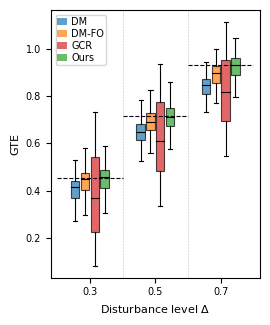

Saved: figures\experiments_20260408_215638\barabasi_lognormal_sweep_disturbance\barabasi_lognormal_sweep_disturbance_phi_varphi_theta_shift_GTE_estimate_boxplot.png


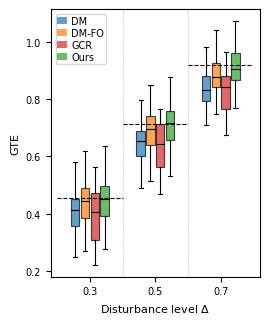

Saved: figures\experiments_20260408_215638\barabasi_uniform_more_shares\barabasi_uniform_more_shares_phi_varphi_theta_shift_GTE_estimate_boxplot.png


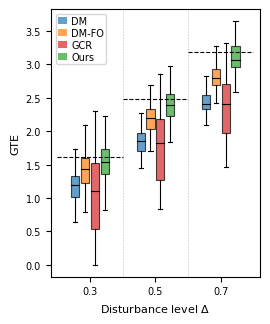

Saved: figures\experiments_20260408_215638\barabasi_uniform_sweep_degree\barabasi_uniform_sweep_degree_graph_GTE_estimate_boxplot.png


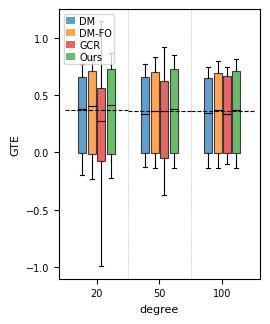

Saved: figures\experiments_20260408_215638\barabasi_uniform_sweep_disturbance\barabasi_uniform_sweep_disturbance_phi_varphi_theta_shift_GTE_estimate_boxplot.png


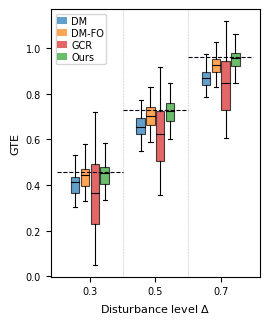

Saved: figures\experiments_20260408_215638\barabasi_uniform_sweep_disturbance2\barabasi_uniform_sweep_disturbance2_phi_varphi_theta_shift_GTE_estimate_boxplot.png


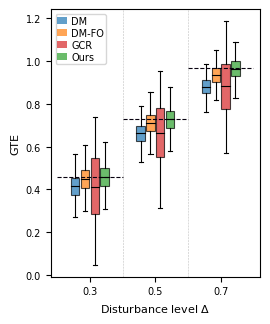

Saved: figures\experiments_20260408_215638\barabasi_uniform_sweep_n\barabasi_uniform_sweep_n_graph_GTE_estimate_boxplot.png


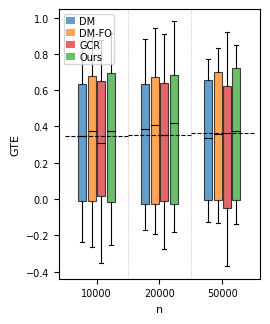

Saved: figures\experiments_20260408_215638\watts_uniform_sweep_rewiring_p\watts_uniform_sweep_rewiring_p_graph_GTE_estimate_boxplot.png


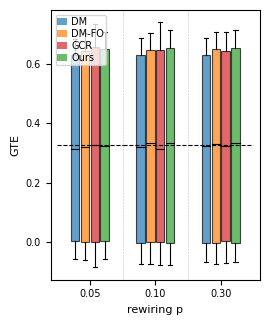

Saved: figures\experiments_20260408_215638\watts_uniform_sweep_degree\watts_uniform_sweep_degree_graph_GTE_estimate_boxplot.png


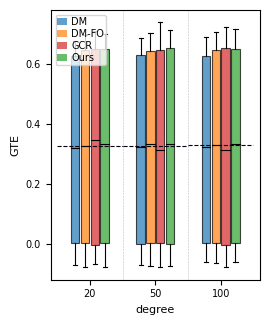

Saved: figures\experiments_20260408_215638\sbm_uniform_sweep_block_num\sbm_uniform_sweep_block_num_graph_GTE_estimate_boxplot.png


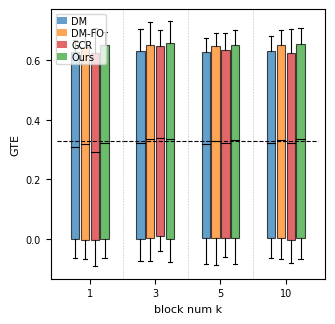

Saved: figures\experiments_20260408_215638\barabasi_gamma_sweep_disturbance\barabasi_gamma_sweep_disturbance_phi_varphi_theta_shift_GTE_mse.png


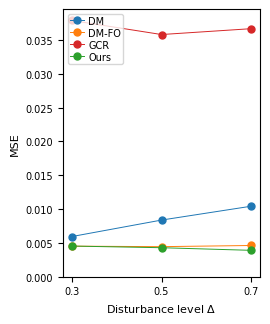

Saved: figures\experiments_20260408_215638\barabasi_lognormal_sweep_disturbance\barabasi_lognormal_sweep_disturbance_phi_varphi_theta_shift_GTE_mse.png


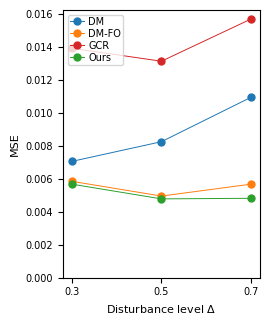

Saved: figures\experiments_20260408_215638\barabasi_uniform_more_shares\barabasi_uniform_more_shares_phi_varphi_theta_shift_GTE_mse.png


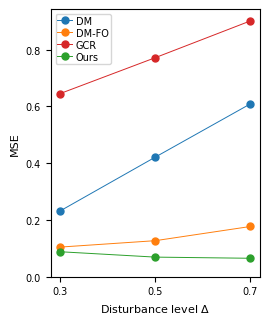

Saved: figures\experiments_20260408_215638\barabasi_uniform_sweep_degree\barabasi_uniform_sweep_degree_graph_GTE_mse.png


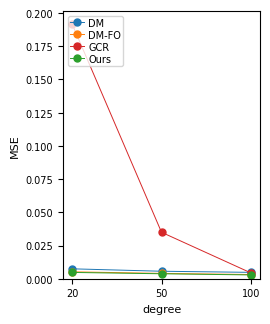

Saved: figures\experiments_20260408_215638\barabasi_uniform_sweep_disturbance\barabasi_uniform_sweep_disturbance_phi_varphi_theta_shift_GTE_mse.png


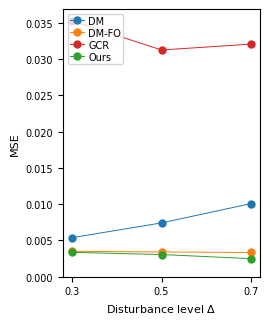

Saved: figures\experiments_20260408_215638\barabasi_uniform_sweep_disturbance2\barabasi_uniform_sweep_disturbance2_phi_varphi_theta_shift_GTE_mse.png


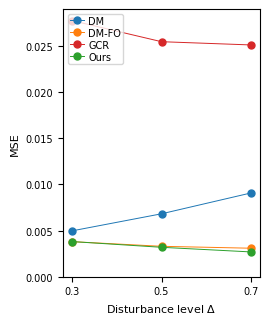

Saved: figures\experiments_20260408_215638\barabasi_uniform_sweep_n\barabasi_uniform_sweep_n_graph_GTE_mse.png


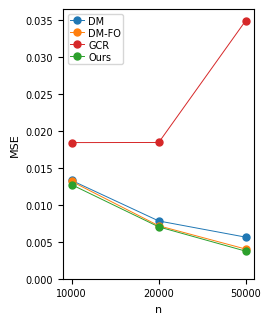

Saved: figures\experiments_20260408_215638\watts_uniform_sweep_rewiring_p\watts_uniform_sweep_rewiring_p_graph_GTE_mse.png


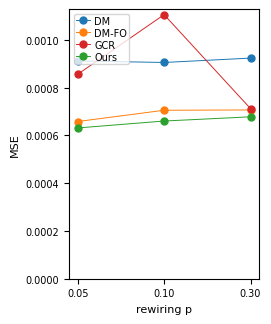

Saved: figures\experiments_20260408_215638\watts_uniform_sweep_degree\watts_uniform_sweep_degree_graph_GTE_mse.png


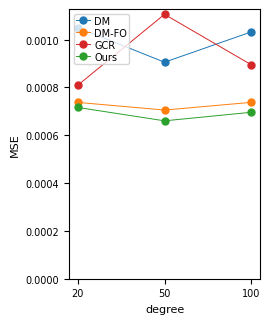

Saved: figures\experiments_20260408_215638\sbm_uniform_sweep_block_num\sbm_uniform_sweep_block_num_graph_GTE_mse.png


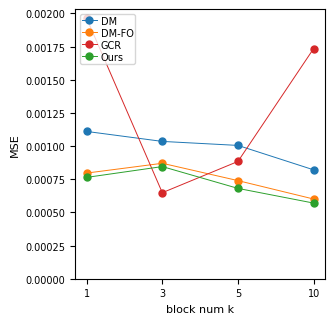

Saved figures:
figures\experiments_20260408_215638\barabasi_gamma_sweep_disturbance\barabasi_gamma_sweep_disturbance_phi_varphi_theta_shift_GTE_estimate_boxplot.png
figures\experiments_20260408_215638\barabasi_lognormal_sweep_disturbance\barabasi_lognormal_sweep_disturbance_phi_varphi_theta_shift_GTE_estimate_boxplot.png
figures\experiments_20260408_215638\barabasi_uniform_more_shares\barabasi_uniform_more_shares_phi_varphi_theta_shift_GTE_estimate_boxplot.png
figures\experiments_20260408_215638\barabasi_uniform_sweep_degree\barabasi_uniform_sweep_degree_graph_GTE_estimate_boxplot.png
figures\experiments_20260408_215638\barabasi_uniform_sweep_disturbance\barabasi_uniform_sweep_disturbance_phi_varphi_theta_shift_GTE_estimate_boxplot.png
figures\experiments_20260408_215638\barabasi_uniform_sweep_disturbance2\barabasi_uniform_sweep_disturbance2_phi_varphi_theta_shift_GTE_estimate_boxplot.png
figures\experiments_20260408_215638\barabasi_uniform_sweep_n\barabasi_uniform_sweep_n_graph_GTE_es

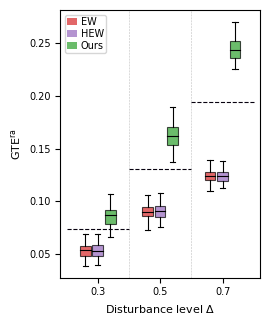

Saved: figures\experiments_20260408_215638\barabasi_uniform_sweep_disturbance\barabasi_uniform_sweep_disturbance_phi_varphi_theta_shift_GTE_ra_mse.png


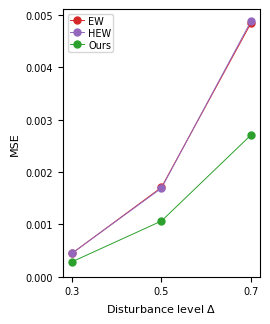

Saved figures:
figures\experiments_20260408_215638\barabasi_uniform_sweep_disturbance\barabasi_uniform_sweep_disturbance_phi_varphi_theta_shift_GTE_ra_estimate_boxplot.png
figures\experiments_20260408_215638\barabasi_uniform_sweep_disturbance\barabasi_uniform_sweep_disturbance_phi_varphi_theta_shift_GTE_ra_mse.png

### manual_rho0 ###
Loaded rows: 1,600
Settings: ['manual_rho0']
Methods: ['naive_HT_share_GTE', 'propagation_share_GTE', 'cluster_mean_share_GTE', 'proposed_share_GTE']
Truth column: truth_share_GTE

=== manual_rho0 ===
[x=0.05]
           bias        se       mse
DM    -0.006949  0.005185  0.002710
DM-FO -0.002321  0.005336  0.002824
GCR   -0.005537  0.007727  0.004807
Ours  -0.001280  0.005292  0.002774
[x=0.2]
           bias        se       mse
DM    -0.133743  0.020132  0.058010
DM-FO -0.058037  0.021866  0.050702
GCR   -0.109520  0.029895  0.083493
Ours  -0.027969  0.022718  0.051875
[x=0.5]
           bias        se       mse
DM    -1.222601  0.075843  2.064215
DM-FO

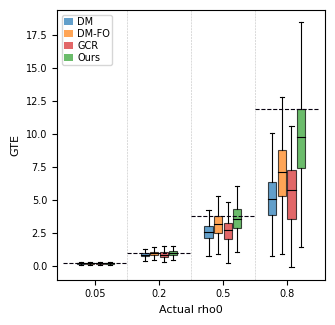

Saved: figures\experiments_20260410_195118\manual_rho0\manual_rho0_rho0_GTE_mse.png


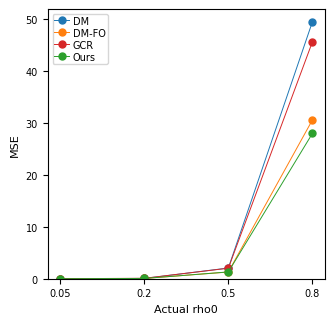

Saved figures:
figures\experiments_20260410_195118\manual_rho0\manual_rho0_rho0_GTE_estimate_boxplot.png
figures\experiments_20260410_195118\manual_rho0\manual_rho0_rho0_GTE_mse.png

### manual_W ###
Loaded rows: 2,000
Settings: ['manual_W']
Methods: ['naive_HT_share_GTE', 'propagation_share_GTE', 'cluster_mean_share_GTE', 'proposed_share_GTE']
Truth column: truth_share_GTE

=== manual_W ===
[x=0]
           bias        se       mse
DM    -0.045869  0.011591  0.015404
DM-FO -0.017533  0.012144  0.014907
GCR   -0.040759  0.014196  0.017784
Ours  -0.006645  0.012471  0.015441
[x=5]
           bias        se       mse
DM    -0.050318  0.011947  0.016662
DM-FO -0.019215  0.012558  0.015982
GCR   -0.041910  0.015278  0.020430
Ours  -0.007542  0.012909  0.016555
[x=10]
           bias        se       mse
DM    -0.050493  0.011962  0.016716
DM-FO -0.019327  0.012576  0.016032
GCR   -0.042102  0.015251  0.020381
Ours  -0.007611  0.012929  0.016608
[x=24]
           bias        se       mse
DM 

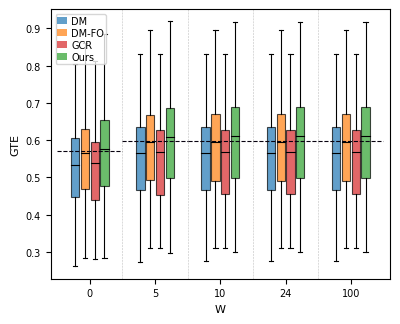

Saved: figures\experiments_20260410_195116\manual_W\manual_W_W_GTE_mse.png


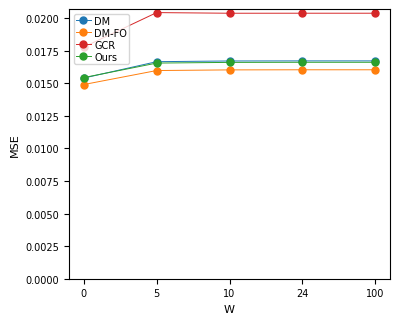

Saved figures:
figures\experiments_20260410_195116\manual_W\manual_W_W_GTE_estimate_boxplot.png
figures\experiments_20260410_195116\manual_W\manual_W_W_GTE_mse.png

### manual_bayesian ###
Loaded rows: 1,500
Settings: ['manual_bayesian']
Methods: ['naive_HT_share_GTE', 'propagation_share_GTE', 'cluster_mean_share_GTE', 'bayesian_bgps_share_GTE', 'proposed_share_GTE']
Truth column: truth_share_GTE

=== manual_bayesian ===
[x=0.3]
           bias        se       mse
DM    -0.036417  0.013890  0.020428
DM-FO -0.012481  0.015002  0.022438
GCR   -0.014419  0.017924  0.025908
BGPS   0.119360  0.044679  0.211871
Ours  -0.008096  0.014855  0.021913
[x=0.5]
           bias        se       mse
DM    -0.052503  0.012855  0.019117
DM-FO -0.020367  0.013595  0.018711
GCR   -0.036324  0.016391  0.022813
BGPS   0.073898  0.044291  0.199672
Ours  -0.008407  0.013933  0.019289
[x=0.7]
           bias        se       mse
DM    -0.065628  0.011910  0.018349
DM-FO -0.026488  0.012413  0.015955
GCR   -0.05

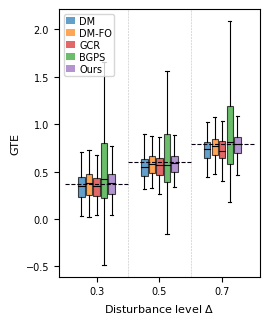

Saved: figures\experiments_20260410_195248\manual_bayesian\manual_bayesian_phi_GTE_mse.png


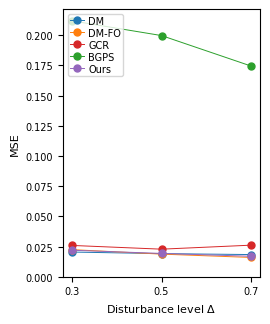

Saved figures:
figures\experiments_20260410_195248\manual_bayesian\manual_bayesian_phi_GTE_estimate_boxplot.png
figures\experiments_20260410_195248\manual_bayesian\manual_bayesian_phi_GTE_mse.png


In [8]:
def _load_current_selection() -> dict[str, Any]:
    if MODE == 'standard':
        methods = list(METHODS_TO_PLOT)
        truth_col = GROUND_TRUTH_COL
        long_df, plot_meta = load_standard_sweep(
            results_root=STANDARD_RESULTS_ROOT,
            selected_settings=SELECTED_SETTINGS,
            methods=methods,
            truth_col=truth_col,
            sweep_key_override=SWEEP_KEY_OVERRIDE,
        )
        long_df, plot_meta = remove_zero_disturbance_cases(long_df, plot_meta)
        return {
            'name': 'standard_main',
            'long_df': long_df,
            'plot_meta': plot_meta,
            'methods': methods,
            'truth_col': truth_col,
            'method_labels': METHOD_LABELS,
            'method_colors': METHOD_COLORS,
            'metric_name': METRIC_NAME,
            'metric_label': METRIC_LABEL,
            'boxplot_mode': BOXPLOT_MODE,
            'legend_pos': LEGEND_POS,
            'mse_legend_overrides': MSE_LEGEND_OVERRIDES,
        }

    if MODE == 'manual':
        if MANUAL_PRESET not in MANUAL_SPECS:
            raise ValueError(f'MANUAL_PRESET must be one of {sorted(MANUAL_SPECS)}')
        manual_spec = MANUAL_SPECS[MANUAL_PRESET]
        methods = list(manual_spec.get('methods', METHODS_TO_PLOT))
        truth_col = str(manual_spec.get('truth_col', GROUND_TRUTH_COL))
        long_df, plot_meta = load_manual_folder_sweep(
            spec=manual_spec,
            methods=methods,
            truth_col=truth_col,
        )
        long_df, plot_meta = remove_zero_disturbance_cases(long_df, plot_meta)
        return {
            'name': str(manual_spec.get('name', MANUAL_PRESET)),
            'long_df': long_df,
            'plot_meta': plot_meta,
            'methods': methods,
            'truth_col': truth_col,
            'method_labels': manual_spec.get('method_labels', METHOD_LABELS),
            'method_colors': manual_spec.get('method_colors', METHOD_COLORS),
            'metric_name': str(manual_spec.get('metric_name', METRIC_NAME)),
            'metric_label': manual_spec.get('metric_label', METRIC_LABEL),
            'boxplot_mode': str(manual_spec.get('boxplot_mode', BOXPLOT_MODE)),
            'legend_pos': str(manual_spec.get('legend_pos', LEGEND_POS)),
            'mse_legend_overrides': {},
        }

    raise ValueError("MODE must be 'standard' or 'manual'")


def _load_standard_extra_plot(extra_spec: dict[str, Any]) -> dict[str, Any]:
    methods = list(extra_spec.get('methods', METHODS_TO_PLOT))
    truth_col = str(extra_spec.get('truth_col', GROUND_TRUTH_COL))
    results_root = Path(extra_spec.get('results_root', STANDARD_RESULTS_ROOT))
    selected_settings = list(extra_spec.get('selected_settings', SELECTED_SETTINGS))
    long_df, plot_meta = load_standard_sweep(
        results_root=results_root,
        selected_settings=selected_settings,
        methods=methods,
        truth_col=truth_col,
        sweep_key_override=extra_spec.get('sweep_key_override') or SWEEP_KEY_OVERRIDE,
    )
    long_df, plot_meta = remove_zero_disturbance_cases(long_df, plot_meta)
    return {
        'name': str(extra_spec.get('name', '_'.join(selected_settings))),
        'long_df': long_df,
        'plot_meta': plot_meta,
        'methods': methods,
        'truth_col': truth_col,
        'method_labels': extra_spec.get('method_labels', METHOD_LABELS),
        'method_colors': extra_spec.get('method_colors', METHOD_COLORS),
        'metric_name': str(extra_spec.get('metric_name', METRIC_NAME)),
        'metric_label': extra_spec.get('metric_label', METRIC_LABEL),
        'boxplot_mode': str(extra_spec.get('boxplot_mode', BOXPLOT_MODE)),
        'legend_pos': str(extra_spec.get('legend_pos', LEGEND_POS)),
        'mse_legend_overrides': extra_spec.get('mse_legend_overrides', {}),
    }


def _load_manual_plot(preset_name: str) -> dict[str, Any]:
    if preset_name not in MANUAL_SPECS:
        raise ValueError(f'MANUAL_PLOTS contains unknown preset {preset_name!r}; choose from {sorted(MANUAL_SPECS)}')
    manual_spec = MANUAL_SPECS[preset_name]
    methods = list(manual_spec.get('methods', METHODS_TO_PLOT))
    truth_col = str(manual_spec.get('truth_col', GROUND_TRUTH_COL))
    long_df, plot_meta = load_manual_folder_sweep(
        spec=manual_spec,
        methods=methods,
        truth_col=truth_col,
    )
    long_df, plot_meta = remove_zero_disturbance_cases(long_df, plot_meta)
    return {
        'name': str(manual_spec.get('name', preset_name)),
        'long_df': long_df,
        'plot_meta': plot_meta,
        'methods': methods,
        'truth_col': truth_col,
        'method_labels': manual_spec.get('method_labels', METHOD_LABELS),
        'method_colors': manual_spec.get('method_colors', METHOD_COLORS),
        'metric_name': str(manual_spec.get('metric_name', METRIC_NAME)),
        'metric_label': manual_spec.get('metric_label', METRIC_LABEL),
        'boxplot_mode': str(manual_spec.get('boxplot_mode', BOXPLOT_MODE)),
        'legend_pos': str(manual_spec.get('legend_pos', LEGEND_POS)),
        'mse_legend_overrides': {},
    }


def _plot_suite(suite: dict[str, Any]) -> dict[str, Any]:
    suite_metrics_df = calc_metrics(suite['long_df'])
    print(f"\n### {suite['name']} ###")
    print(f"Loaded rows: {len(suite['long_df']):,}")
    print(f"Settings: {list(suite['plot_meta']['settings'].keys())}")
    print(f"Methods: {suite['methods']}")
    print(f"Truth column: {suite['truth_col']}")
    print_metrics_table(suite_metrics_df, suite['methods'], suite['method_labels'])

    suite_boxplot_paths = plot_grouped_boxplot(
        long_df=suite['long_df'],
        meta=suite['plot_meta'],
        methods=suite['methods'],
        method_label_map=suite['method_labels'],
        method_colors=suite['method_colors'],
        metric_name=suite['metric_name'],
        metric_label=suite['metric_label'],
        boxplot_mode=suite['boxplot_mode'],
        legend_pos=suite['legend_pos'],
        save_fig=SAVE_FIG,
    )

    suite_mse_paths = plot_mse_curve(
        metrics_df=suite_metrics_df,
        meta=suite['plot_meta'],
        methods=suite['methods'],
        method_label_map=suite['method_labels'],
        method_colors=suite['method_colors'],
        metric_name=suite['metric_name'],
        legend_pos=suite['legend_pos'],
        legend_overrides_by_setting=suite.get('mse_legend_overrides'),
        save_fig=SAVE_FIG,
    )

    print('Saved figures:')
    for path in suite_boxplot_paths + suite_mse_paths:
        print(path)

    return {
        'name': suite['name'],
        'metrics_df': suite_metrics_df,
        'boxplot_paths': suite_boxplot_paths,
        'mse_paths': suite_mse_paths,
    }


plot_suites = [_load_current_selection()]
if MODE == 'standard':
    plot_suites.extend(
        _load_standard_extra_plot(extra_spec)
        for extra_spec in STANDARD_EXTRA_PLOTS
        if extra_spec.get('enabled', True)
    )

manual_presets_to_plot = list(MANUAL_PLOTS)
if MODE == 'manual':
    manual_presets_to_plot = [preset for preset in manual_presets_to_plot if preset != MANUAL_PRESET]
plot_suites.extend(_load_manual_plot(preset) for preset in manual_presets_to_plot)

plot_outputs = [_plot_suite(suite) for suite in plot_suites]

# Preserve the original convenience variables for the primary suite.
primary_suite = plot_suites[0]
primary_output = plot_outputs[0]
long_df = primary_suite['long_df']
plot_meta = primary_suite['plot_meta']
METHODS_USED = primary_suite['methods']
TRUTH_COL_USED = primary_suite['truth_col']
METHOD_LABELS_USED = primary_suite['method_labels']
METHOD_COLORS_USED = primary_suite['method_colors']
metrics_df = primary_output['metrics_df']
boxplot_paths = primary_output['boxplot_paths']
mse_paths = primary_output['mse_paths']
all_boxplot_paths = [path for output in plot_outputs for path in output['boxplot_paths']]
all_mse_paths = [path for output in plot_outputs for path in output['mse_paths']]


## Inference / Coverage Summary

In [9]:
from __future__ import annotations


def collect_inference_summaries(root: Path) -> pd.DataFrame:
    rows = []
    for summary_path in Path(root).rglob('inference_summary.json'):
        try:
            payload = json.loads(summary_path.read_text(encoding='utf-8'))
        except json.JSONDecodeError:
            continue
        rows.append({
            'folder': str(summary_path.parent),
            'coverage_rate': payload.get('coverage_rate'),
            'mean_p_value': payload.get('mean_p_value'),
            'inference_type': payload.get('inference_type'),
        })
    return pd.DataFrame(rows, columns=['folder', 'coverage_rate', 'inference_type'])


inference_root = Path(plot_meta['results_root'])
inference_df = collect_inference_summaries(inference_root)
inference_df


,folder,coverage_rate,inference_type
0,results\experiments_20260408_215638\barabasi_g...,0.94,A/A
1,results\experiments_20260408_215638\barabasi_g...,0.94,A/B
2,results\experiments_20260408_215638\barabasi_g...,0.91,A/B
3,results\experiments_20260408_215638\barabasi_g...,0.93,A/B
4,results\experiments_20260408_215638\barabasi_l...,0.91,A/A
...,...,...,...
59,results\experiments_20260408_215638\watts_unif...,0.95,A/B
60,results\experiments_20260408_215638\watts_unif...,0.93,A/A
61,results\experiments_20260408_215638\watts_unif...,0.97,A/B
62,results\experiments_20260408_215638\watts_unif...,0.94,A/A
